In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import sys

sys.path.append("../")

from src.data_loader import DataLoader

loader = DataLoader(
    fraud_path="../data/Fraud_Data.csv",
    ip_path="../data/IpAddress_to_Country.csv",
    credit_path="../data/creditcard.csv"
)

fraud_df = loader.load_fraud_data()

ip_df = loader.load_ipaddress_data()
credit_df = loader.load_creditcard_data()

Text(0.5, 1.0, 'Class Distribution')

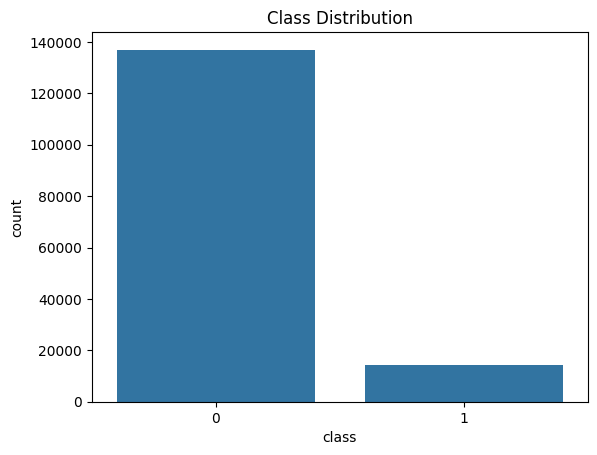

In [11]:
sns.countplot(x="class", data=fraud_df)
plt.title("Class Distribution")

<Axes: xlabel='class', ylabel='purchase_value'>

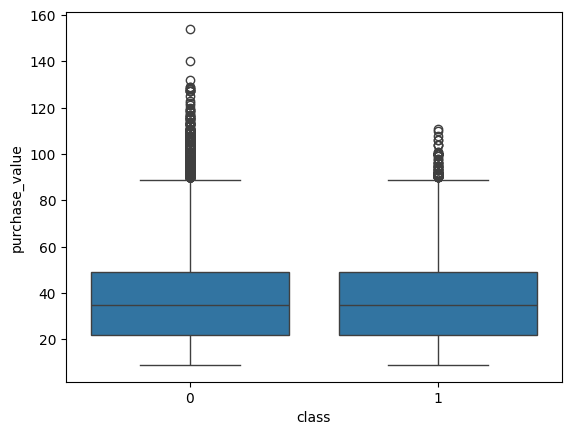

In [12]:
sns.boxplot(x="class", y="purchase_value", data=fraud_df)


In [13]:
fraud_df['class'].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [15]:
fraud_df[fraud_df['class'] == 1]['purchase_value'].describe()

count    14151.000000
mean        36.993004
std         18.397654
min          9.000000
25%         22.000000
50%         35.000000
75%         49.000000
max        111.000000
Name: purchase_value, dtype: float64

In [17]:
fraud_df[fraud_df['class'] == 0]['purchase_value'].describe()


count    136961.000000
mean         36.929418
std          18.315064
min           9.000000
25%          22.000000
50%          35.000000
75%          49.000000
max         154.000000
Name: purchase_value, dtype: float64

In [18]:
credit_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [20]:
from src.eda import EDAExplorer

eda = EDAExplorer(credit_df, target_column='Class')
eda.univariate_summary()

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

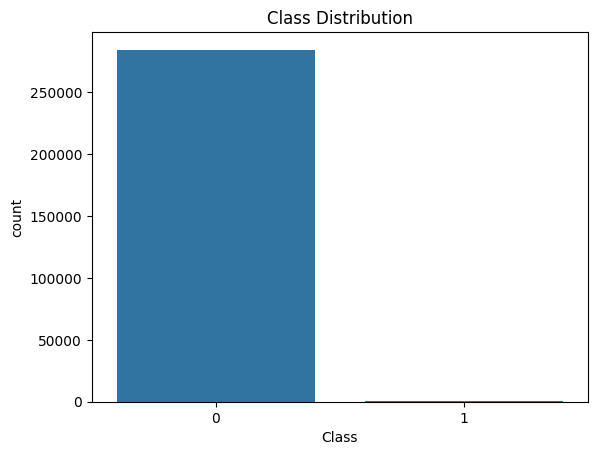

In [21]:
eda.plot_class_distribution()

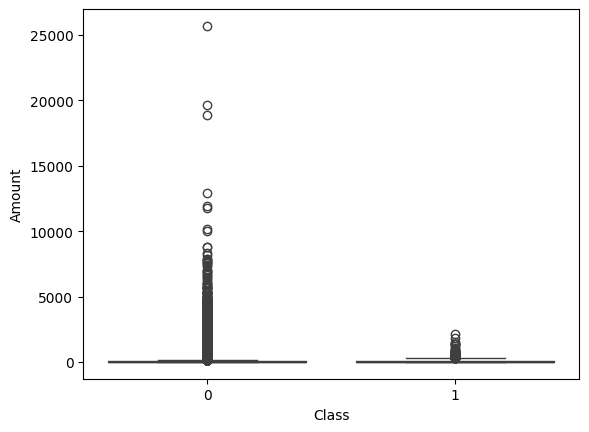

In [23]:
eda.bivariate_plots('Amount') 

In [26]:
credit_df[credit_df['Class'] == 0]['Amount'].describe()


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

In [27]:
credit_df[credit_df['Class'] == 1]['Amount'].describe()


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [28]:
from src.feature_engineer import FeatureEngineer

fe = FeatureEngineer(fraud_df, ip_df)
fe.add_time_features()
fe.add_transaction_velocity()
fe.map_ip_to_country()

final_df = fe.get_engineered_data()
final_df['ip_address'].head()


0    7.327584e+08
1    3.503114e+08
2    2.621474e+09
3    3.840542e+09
4    4.155831e+08
Name: ip_address, dtype: float64

In [29]:

from src.transformer import DataTransformer

dt = DataTransformer(final_df, target_col='class')
dt.split_data()
dt.encode_and_scale()
dt.handle_class_imbalance(method='smote')

X_train, X_test, y_train, y_test = dt.get_transformed_data()
print(X_train.shape, y_train.value_counts())


Dropping high-cardinality columns: ['device_id']
(219136, 17) class
0    109568
1    109568
Name: count, dtype: int64
